# 🤟 Indian Sign Language Translation — Video to Text
**Dataset:** ISL-CSLTR Corpus (ISL_CSLRT_Corpus)
**Stack:** Python 3.10 · MediaPipe · PyTorch · Gradio

---
### Real dataset structure this notebook expects
```
ISL_CSLRT_Corpus/
├── Frames_Sentence_Level/     ← pre-extracted frames per sentence (USE THIS)
├── Frames_Word_Level/         ← pre-extracted frames per word
├── Videos_Sentence_Level/    ← raw .mp4 videos (alternative source)
└── corpus_csv_files/
    ├── ISL_CSLRT_Corpus_*.csv ← annotations (signer, label, paths)
    └── ISL_CSLRT.txt
```

### Run order
| Section | What it does |
|---|---|
| 1 | Install dependencies |
| 2 | Config + explore dataset structure |
| 3 | Read CSV annotations → map frames to labels |
| 4 | Run MediaPipe on frames → save keypoints (.npy) |
| 5 | PyTorch Dataset & DataLoader |
| 6 | Model (BiLSTM with attention) |
| 7 | Train |
| 8 | Evaluate |
| 9 | Real-time inference + Gradio UI |


## Section 1 — Install dependencies
Run once. Restart kernel if asked.

In [1]:
import subprocess, sys

packages = [
    "torch torchvision --index-url https://download.pytorch.org/whl/cpu",
    "opencv-python",
    "mediapipe==0.10.11",
    "scikit-learn",
    "tqdm",
    "jiwer",
    "gradio",
    "matplotlib",
    "pandas",
    "pyyaml",
    "seaborn",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", *pkg.split()], check=True)

print("\n✅ All packages installed!")



✅ All packages installed!


## Section 2 — Config & explore dataset structure
**Edit `DATASET_ROOT` below to point to your `ISL_CSLRT_Corpus` folder.**


In [2]:
import os, json, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ─── EDIT THIS ────────────────────────────────────────────────────────────────
DATASET_ROOT =  r"D:\ISL2\ISL_CSLRT_Corpus"   # ← your path
# ──────────────────────────────────────────────────────────────────────────────

FRAMES_SENTENCE = os.path.join(DATASET_ROOT, "Frames_Sentence_Level")
FRAMES_WORD     = os.path.join(DATASET_ROOT, "Frames_Word_Level")
VIDEOS          = os.path.join(DATASET_ROOT, "Videos_Sentence_Level")
CSV_DIR         = os.path.join(DATASET_ROOT, "corpus_csv_files")
PROCESSED_DIR   = "data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs("checkpoints",  exist_ok=True)

CFG = {
    "max_seq_len":    150,
    "num_keypoints":  1662,   # 33×4 pose + 468×3 face + 21×3 lh + 21×3 rh
    "hidden_size":    256,
    "num_layers":     3,
    "dropout":        0.4,
    "epochs":         80,
    "batch_size":     16,
    "learning_rate":  3e-4,
    "patience":       15,
    "device":         "cuda",  # change to "cpu" if no GPU
    "checkpoint":     "checkpoints/best_model.pt",
    "label_map":      "data/processed/label_map.json",
    "samples":        "data/processed/samples.json",
}

# ── Explore top-level folders ──
print("=== Dataset root contents ===")
for item in sorted(os.listdir(DATASET_ROOT)):
    full = os.path.join(DATASET_ROOT, item)
    if os.path.isdir(full):
        sub_count = len(os.listdir(full))
        print(f"  📁 {item}/  ({sub_count} items)")
    else:
        print(f"  📄 {item}")

# ── Explore CSV files ──
print("\n=== CSV files found ===")
csv_files = list(Path(CSV_DIR).glob("*.csv")) + list(Path(CSV_DIR).glob("*.CSV"))
for f in csv_files:
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

print(f"\n=== Frames_Sentence_Level top folders ===")
if os.path.exists(FRAMES_SENTENCE):
    folders = sorted(os.listdir(FRAMES_SENTENCE))[:20]
    for f in folders:
        sub = os.path.join(FRAMES_SENTENCE, f)
        if os.path.isdir(sub):
            n = len(os.listdir(sub))
            print(f"  {f}/  ({n} items)")


=== Dataset root contents ===
  📁 .git/  (10 items)
  📄 .gitignore
  📄 An_Explicit_Multi-Modal_Fusion_Method_for_Sign_Language_Translation.pdf
  📁 Frames_Sentence_Level/  (97 items)
  📁 Frames_Word_Level/  (114 items)
  📄 HHHHHHHHH.ipynb
  📄 ISL.ipynb
  📄 ISL2.ipynb
  📄 ISL_CSLRT.txt
  📄 ISL_Translation_Full.ipynb
  📄 ISL_Translation_v2.ipynb
  📄 ISL_Translation_v3.ipynb
  📄 Indian_Sign_Language_recognition_and_translation_An_Encoder-Decoder_Approach (1).pdf
  📄 TRY.ipynb
  📁 Videos_Sentence_Level/  (101 items)
  📄 best_emf_slt.pth
  📄 best_isl_model.pth
  📄 best_paper1.pth
  📄 best_resnet18_isl.pth
  📄 best_sen_isl.pth
  📁 checkpoints/  (0 items)
  📁 corpus_csv_files/  (6 items)
  📁 data/  (1 items)
  📄 dataset_meta.csv
  📄 emf_slt.ipynb
  📄 gloss_vocab.json
  📄 main.ipynb
  📄 model_checkpoint.pth
  📄 nb_dump.txt
  📄 paper1_confusion_matrix.png
  📄 paper1_stgcn.ipynb
  📄 paper1_training.png
  📄 paper1_training_curves.png
  📄 paper2_emfslt.ipynb
  📄 paper_extract.txt
  📄 requirements.t

### Preview all CSV files — understand what columns exist

In [3]:
import pandas as pd

all_dfs = {}
for csv_path in sorted(Path(CSV_DIR).glob("*.csv")):
    try:
        df = pd.read_csv(csv_path, encoding="latin-1")   # latin-1 handles 0xa0 bytes
        all_dfs[csv_path.name] = df
        print(f"\n{'─'*60}")
        print(f"FILE : {csv_path.name}")
        print(f"SHAPE: {df.shape}  (rows × cols)")
        print(f"COLS : {list(df.columns)}")
        print(df.head(3).to_string())
    except Exception as e:
        print(f"Could not read {csv_path.name}: {e}")



────────────────────────────────────────────────────────────
FILE : ISL Corpus sign glosses.csv
SHAPE: (101, 2)  (rows × cols)
COLS : ['Sentence', 'SIGN GLOSSES']
                   Sentence        SIGN GLOSSES
0        are you free today      YOU FREE TODAY
1  are you hiding something  YOU HIDE SOMETHING
2        bring water for me      BRING WATER ME

────────────────────────────────────────────────────────────
FILE : ISL_CSLRT_Corpus details.csv
SHAPE: (792, 2)  (rows × cols)
COLS : ['Sentences', 'File location']
            Sentences                                                           File location
0  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (2).MP4
1  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (3).MP4
2  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (4).MP4

────────────────────────────────────────────────────────────
FILE : ISL_CSLRT_Corpus_frame_details.c

## Section 3 — Parse CSV annotations → build sample list
Uses `ISL_CSLRT_Corpus_frame_details.csv` which has 18,863 rows —
one row per frame — with columns `Sentence` and `Frames path`.

We group rows by `(sentence, parent_folder)` so each unique signer recording
becomes one sequence.

> Make sure `DATASET_ROOT` in Section 2 points to the `ISL_CSLRT_Corpus` folder itself.


In [4]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ── Load frame_details CSV (has every frame path + sentence label) ────────────
CSV_PATH = os.path.join(CSV_DIR, "ISL_CSLRT_Corpus_frame_details.csv")
df = pd.read_csv(CSV_PATH, encoding="latin-1")

print(f"Shape : {df.shape}")
print(f"Cols  : {list(df.columns)}")
print()
print(df.head(5).to_string())


Shape : (18863, 2)
Cols  : ['Sentence', 'Frames path']

             Sentence                                                                            Frames path
0  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
1  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 02.jpg
2  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 03.jpg
3  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 04.jpg
4  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 05.jpg


In [5]:
# ── Group rows → one sequence per (sentence, signer folder) ──────────────────
#
# Each "Frames path" value looks like:
#   ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
#
# Parent folder = ...\are you free today\1  → one sequence (one signer recording)
# We strip the leading "ISL_CSLRT_Corpus\" and join with DATASET_ROOT.

groups = defaultdict(list)

for _, row in df.iterrows():
    sentence = str(row["Sentence"]).strip()
    raw_path = str(row["Frames path"]).strip()

    # Normalize path separators for Windows/Linux compatibility
    raw_path = raw_path.replace("\\", os.sep).replace("/", os.sep)

    # Strip the leading "ISL_CSLRT_Corpus" folder name stored in the CSV
    parts = raw_path.split(os.sep)
    if parts and parts[0] == "ISL_CSLRT_Corpus":
        parts = parts[1:]
    abs_path = os.path.join(DATASET_ROOT, *parts)

    # Parent folder = sequence key  (strips the filename)
    folder = str(Path(abs_path).parent)
    groups[(sentence, folder)].append(abs_path)

# ── Build raw_samples list ────────────────────────────────────────────────────
raw_samples = []
for (sentence, folder), frame_paths in groups.items():
    sorted_frames = sorted(frame_paths, key=lambda p: Path(p).name)
    raw_samples.append({
        "label":       sentence,
        "frame_paths": sorted_frames,        # ordered list of absolute .jpg paths
        "num_frames":  len(sorted_frames),
    })

total_classes = len(set(s["label"] for s in raw_samples))
avg_frames    = sum(s["num_frames"] for s in raw_samples) / max(len(raw_samples), 1)

print(f"✅ {len(raw_samples)} sequences  |  {total_classes} unique classes")
print(f"   Avg frames/sequence : {avg_frames:.1f}")

# ── Spot-check: verify first 3 paths actually exist on disk ──────────────────
print("\nSpot-checking paths:")
all_ok = True
for s in raw_samples[:3]:
    first  = s["frame_paths"][0]
    exists = os.path.exists(first)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  label='{s['label']}'  frames={s['num_frames']}")
    print(f"            {first}")
    if not exists:
        all_ok = False

if not all_ok:
    print(f"\n⚠ Paths not found — check DATASET_ROOT = '{DATASET_ROOT}'")
    print("  It must point TO the ISL_CSLRT_Corpus folder, e.g.:")
    print("  DATASET_ROOT = r'C:/Downloads/ISL_CSLRT_Corpus'")
else:
    print("\n✅ All paths verified — ready for Section 4!")


✅ 663 sequences  |  97 unique classes
   Avg frames/sequence : 28.5

Spot-checking paths:
  ✅  label='are you free today'  frames=22
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
  ✅  label='are you free today'  frames=12
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\2\are you free today (2) 01.jpg
  ✅  label='are you free today'  frames=42
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\3\free 01.jpg

✅ All paths verified — ready for Section 4!


## Section 4 — MediaPipe keypoint extraction from frames
Since the dataset already has **pre-extracted frames**, we run MediaPipe directly  
on the images (much faster than processing videos frame-by-frame).  
Output: one `.npy` file per sequence saved to `data/processed/`.


In [10]:
import cv2, numpy as np, mediapipe as mp
from tqdm.auto import tqdm
import json, os

mp_holistic = mp.solutions.holistic

def extract_keypoints(results):
    """Only hands + pose — skip face (468 landmarks = 80% of processing time)."""
    pose = np.array([[r.x, r.y, r.z, r.visibility]
                     for r in results.pose_landmarks.landmark]).flatten() \
           if results.pose_landmarks else np.zeros(33 * 4)

    # Face zeroed out — not needed for sign language recognition
    face = np.zeros(468 * 3)

    lh   = np.array([[r.x, r.y, r.z]
                     for r in results.left_hand_landmarks.landmark]).flatten() \
           if results.left_hand_landmarks else np.zeros(21 * 3)
    rh   = np.array([[r.x, r.y, r.z]
                     for r in results.right_hand_landmarks.landmark]).flatten() \
           if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([pose, face, lh, rh])   # still (1662,) — shape unchanged

# ── Build label map ────────────────────────────────────────────────────────────
unique_labels = sorted(set(s["label"] for s in raw_samples))
label_map     = {lbl: idx for idx, lbl in enumerate(unique_labels)}
id2label      = {v: k for k, v in label_map.items()}
print(f"Classes : {len(label_map)}")
print(f"Labels  : {list(label_map.keys())[:8]} ...")
print(f"Total sequences to process: {len(raw_samples)}")

# ── Extract keypoints ──────────────────────────────────────────────────────────
processed_samples = []
skipped = 0

with mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    static_image_mode=True,
    enable_segmentation=False,       # ← skip segmentation mask (saves time)
    refine_face_landmarks=False,     # ← skip iris refinement (saves time)
    model_complexity=0,              # ← 0 = fastest model, 2 = most accurate
) as holistic:
    for s in tqdm(raw_samples, desc="Extracting keypoints"):
        kps_list = []
        for img_path in s["frame_paths"]:
            frame = cv2.imread(img_path)
            if frame is None:
                continue

            # Resize to 256×256 before MediaPipe — original resolution is overkill
            frame   = cv2.resize(frame, (256, 256))
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)
            kps_list.append(extract_keypoints(results))

        if len(kps_list) == 0:
            skipped += 1
            continue

        seq       = np.array(kps_list, dtype=np.float32)
        safe_name = s["label"].replace(" ", "_").replace("/", "-")
        uid       = abs(hash(s["frame_paths"][0])) % 100000
        save_path = os.path.join(PROCESSED_DIR, f"{safe_name}__{uid}.npy")
        np.save(save_path, seq)
        processed_samples.append({"path": save_path, "label": s["label"]})

print(f"\n✅ Done!  {len(processed_samples)} sequences saved  |  {skipped} skipped")
print(f"   Stored in : {PROCESSED_DIR}/")

json.dump(label_map,         open(CFG["label_map"], "w"), indent=2)
json.dump(processed_samples, open(CFG["samples"],   "w"), indent=2)
print(f"   label_map → {CFG['label_map']}")
print(f"   samples   → {CFG['samples']}")

Classes : 97
Labels  : ['He is going into the room', 'This place is beautiful', 'are you free today', 'are you hiding something', 'bring water for me', 'can i help you', 'can you repeat that please', 'comb your hair'] ...
Total sequences to process: 663

























































































































































































































































































































































































































































































































































































































































































Extracting keypoints: 100%|██████████| 663/663 [19:00<00:00,  1.72s/it]


✅ Done!  662 sequences saved  |  1 skipped
   Stored in : data/processed/
   label_map → data/processed/label_map.json
   samples   → data/processed/samples.json


### Sanity check — visualise one keypoint sequence

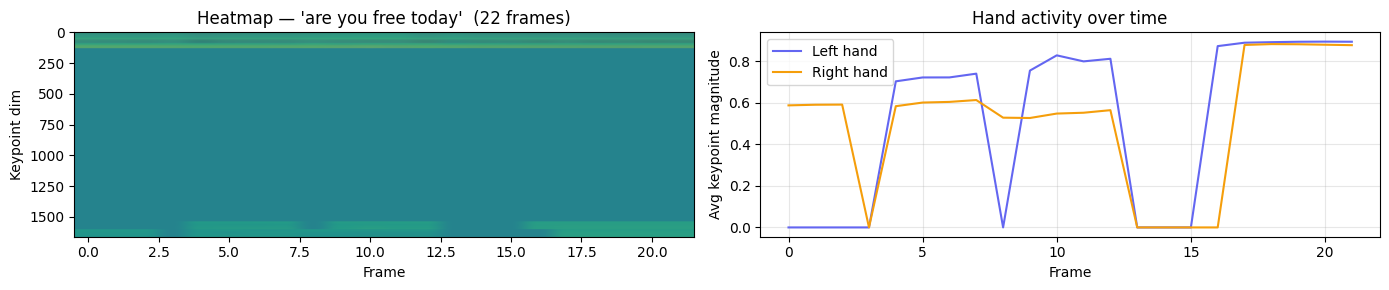

Sequence shape : (22, 1662)  (frames × keypoints)
Value range    : -1.558 → 1.927


In [11]:
import matplotlib.pyplot as plt

s   = processed_samples[0]
seq = np.load(s["path"])

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].imshow(seq.T, aspect="auto", cmap="viridis")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Keypoint dim")
axes[0].set_title(f"Heatmap — '{s['label']}'  ({seq.shape[0]} frames)")

# Plot hand keypoint magnitude over time
lh_start, lh_end = 33*4 + 468*3, 33*4 + 468*3 + 21*3
rh_start, rh_end = lh_end, lh_end + 21*3
lh_mag = np.linalg.norm(seq[:, lh_start:lh_end].reshape(seq.shape[0], 21, 3), axis=2).mean(1)
rh_mag = np.linalg.norm(seq[:, rh_start:rh_end].reshape(seq.shape[0], 21, 3), axis=2).mean(1)
axes[1].plot(lh_mag, label="Left hand",  color="#6366F1")
axes[1].plot(rh_mag, label="Right hand", color="#F59E0B")
axes[1].set_xlabel("Frame"); axes[1].set_ylabel("Avg keypoint magnitude")
axes[1].set_title("Hand activity over time")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Sequence shape : {seq.shape}  (frames × keypoints)")
print(f"Value range    : {seq.min():.3f} → {seq.max():.3f}")


## Section 5 — PyTorch Dataset & DataLoader

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

MAX_LEN   = CFG["max_seq_len"]
NUM_FEATS = CFG["num_keypoints"]

class ISLDataset(Dataset):
    def __init__(self, samples, label_map):
        self.samples   = samples
        self.label_map = label_map

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        seq = np.load(s["path"])
        T   = seq.shape[0]

        if T >= MAX_LEN:
            seq  = seq[:MAX_LEN]
            mask = np.ones(MAX_LEN, dtype=np.float32)
        else:
            pad  = np.zeros((MAX_LEN - T, NUM_FEATS), dtype=np.float32)
            seq  = np.concatenate([seq, pad], axis=0)
            mask = np.array([1.]*T + [0.]*(MAX_LEN-T), dtype=np.float32)

        label = self.label_map[s["label"]]
        return (
            torch.tensor(seq,   dtype=torch.float32),
            torch.tensor(mask,  dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

# ── Reload saved metadata ──────────────────────────────────────────────────────
processed_samples = json.load(open(CFG["samples"]))
label_map         = json.load(open(CFG["label_map"]))
id2label          = {int(v): k for k, v in label_map.items()}
NUM_CLASSES       = len(label_map)

# ── Fix: remove classes that have only 1 sample (can't stratify split) ────────
count = Counter(s["label"] for s in processed_samples)
before = len(processed_samples)
processed_samples = [s for s in processed_samples if count[s["label"]] >= 3]
removed = before - len(processed_samples)
if removed:
    print(f"⚠ Removed {removed} samples from {sum(1 for c in count.values() if c < 3)} "
          f"classes that had fewer than 3 samples (not enough to split).")

labels_all = [s["label"] for s in processed_samples]

# ── First split: 70% train, 30% temp ──────────────────────────────────────────
train_s, temp_s = train_test_split(
    processed_samples, test_size=0.30,
    stratify=labels_all, random_state=42
)

# ── Second split: 15% val, 15% test ───────────────────────────────────────────
# Use stratify only if every class in temp_s has ≥ 2 samples
temp_labels = [s["label"] for s in temp_s]
temp_count  = Counter(temp_labels)
can_stratify = all(v >= 2 for v in temp_count.values())

val_s, test_s = train_test_split(
    temp_s, test_size=0.50,
    stratify=temp_labels if can_stratify else None,
    random_state=42
)

if not can_stratify:
    print("⚠ Some classes had only 1 sample in temp split — "
          "stratification skipped for val/test split.")

print(f"\n✅ Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}")
print(f"   Classes: {NUM_CLASSES}")

BS = CFG["batch_size"]
train_loader = DataLoader(ISLDataset(train_s, label_map), batch_size=BS,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(ISLDataset(val_s,   label_map), batch_size=BS,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(ISLDataset(test_s,  label_map), batch_size=BS,
                          shuffle=False, num_workers=0)

seqs, masks, labels = next(iter(train_loader))
print(f"   Batch — seqs {tuple(seqs.shape)} | masks {tuple(masks.shape)} "
      f"| labels {tuple(labels.shape)}")

⚠ Some classes had only 1 sample in temp split — stratification skipped for val/test split.

✅ Train: 463 | Val: 99 | Test: 100
   Classes: 97
   Batch — seqs (16, 150, 1662) | masks (16, 150) | labels (16,)


## Section 6 — Model

In [14]:
import torch.nn as nn

class ISL_BiLSTM(nn.Module):
    """Bidirectional LSTM with temporal attention for ISL classification."""
    def __init__(self, input_size=1662, num_classes=100):
        super().__init__()
        h  = CFG["hidden_size"]
        L  = CFG["num_layers"]
        dp = CFG["dropout"]

        self.input_norm = nn.LayerNorm(input_size)
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=h, num_layers=L,
                            batch_first=True, bidirectional=True,
                            dropout=dp if L > 1 else 0.0)
        self.attn    = nn.Linear(h * 2, 1)
        self.dropout = nn.Dropout(dp)
        self.fc      = nn.Linear(h * 2, num_classes)

    def forward(self, x, mask=None):
        x       = self.input_norm(x)
        out, _  = self.lstm(x)                              # (B, T, 2H)
        scores  = self.attn(out).squeeze(-1)                # (B, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = (out * weights).sum(dim=1)                # (B, 2H)
        return self.fc(self.dropout(context))

DEVICE = torch.device(CFG["device"] if torch.cuda.is_available() else "cpu")
model  = ISL_BiLSTM(input_size=NUM_FEATS, num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model  : ISL_BiLSTM")
print(f"   Device : {DEVICE}")
print(f"   Params : {total_params:,}")


✅ Model  : ISL_BiLSTM
   Device : cuda
   Params : 7,139,678


## Section 7 — Train

In [16]:
from tqdm.auto import tqdm
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["learning_rate"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, patience_ctr = 0.0, 0

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, masks, lbls in tqdm(train_loader, desc=f"Ep {epoch:03d} [train]", leave=False):
        seqs, masks, lbls = seqs.to(DEVICE), masks.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(seqs, masks)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)

    train_acc = correct / total
    avg_loss  = total_loss / len(train_loader)

    model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for seqs, masks, lbls in val_loader:
            seqs, masks = seqs.to(DEVICE), masks.to(DEVICE)
            out = model(seqs, masks)
            vc += (out.argmax(1) == lbls.to(DEVICE)).sum().item()
            vt += lbls.size(0)
    val_acc = vc / vt
    scheduler.step()

    history["train_loss"].append(avg_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    indicator = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save({"model_state": model.state_dict(), "label_map": label_map,
                    "config": CFG}, CFG["checkpoint"])
        indicator = "  ← best ✓"
    else:
        patience_ctr += 1
        if patience_ctr >= CFG["patience"]:
            print("\n⏹ Early stopping.")
            break

    print(f"Ep {epoch:03d} | loss {avg_loss:.4f} | train {train_acc:.3f} | val {val_acc:.3f}{indicator}")

print(f"\n✅ Best val accuracy: {best_val_acc:.4f}")


Ep 001 | loss 4.6013 | train 0.006 | val 0.010  ← best ✓


Ep 002 | loss 4.5880 | train 0.006 | val 0.010


Ep 003 | loss 4.5843 | train 0.004 | val 0.000


Ep 004 | loss 4.5706 | train 0.015 | val 0.010


Ep 005 | loss 4.5574 | train 0.015 | val 0.010


...

Ep 036 | loss 2.4963 | train 0.512 | val 0.030


Ep 037 | loss 2.4200 | train 0.577 | val 0.051


Ep 038 | loss 2.3856 | train 0.557 | val 0.040


Ep 039 | loss 2.2895 | train 0.616 | val 0.051



⏹ Early stopping.

✅ Best val accuracy: 0.0606


### Training curves

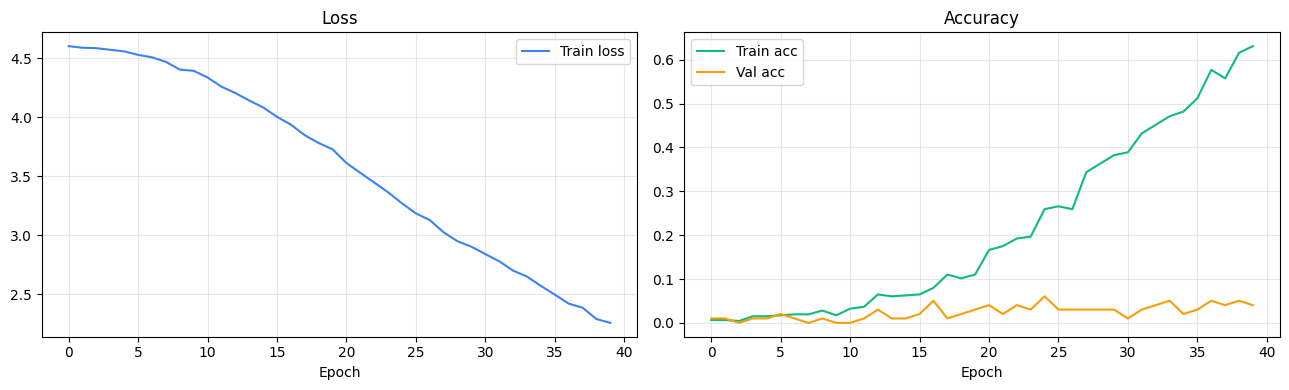

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], color="#3B82F6", label="Train loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["train_acc"], color="#10B981", label="Train acc")
axes[1].plot(history["val_acc"],   color="#F59E0B", label="Val acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()


## Section 8 — Evaluate on test set

In [18]:
from jiwer import wer as compute_wer
import seaborn as sns
from sklearn.metrics import confusion_matrix

ckpt = torch.load(CFG["checkpoint"], map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

refs, hyps = [], []
with torch.no_grad():
    for seqs, masks, lbls in tqdm(test_loader, desc="Testing"):
        out   = model(seqs.to(DEVICE), masks.to(DEVICE))
        preds = out.argmax(1).cpu().tolist()
        for p, t in zip(preds, lbls.tolist()):
            hyps.append(id2label[p])
            refs.append(id2label[t])

acc     = sum(h==r for h,r in zip(hyps,refs)) / len(refs)
word_er = compute_wer(refs, hyps)

print(f"{'='*45}")
print(f"  Test accuracy  : {acc:.4f}  ({int(acc*len(refs))}/{len(refs)})")
print(f"  Word error rate: {word_er:.4f}")
print(f"{'='*45}")


C:\Users\harsh\AppData\Local\Temp\ipykernel_19944\292566219.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG["checkpoint"], map_location=DEVICE)
Tes

  Test accuracy  : 0.0500  (5/100)
  Word error rate: 1.0458


C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


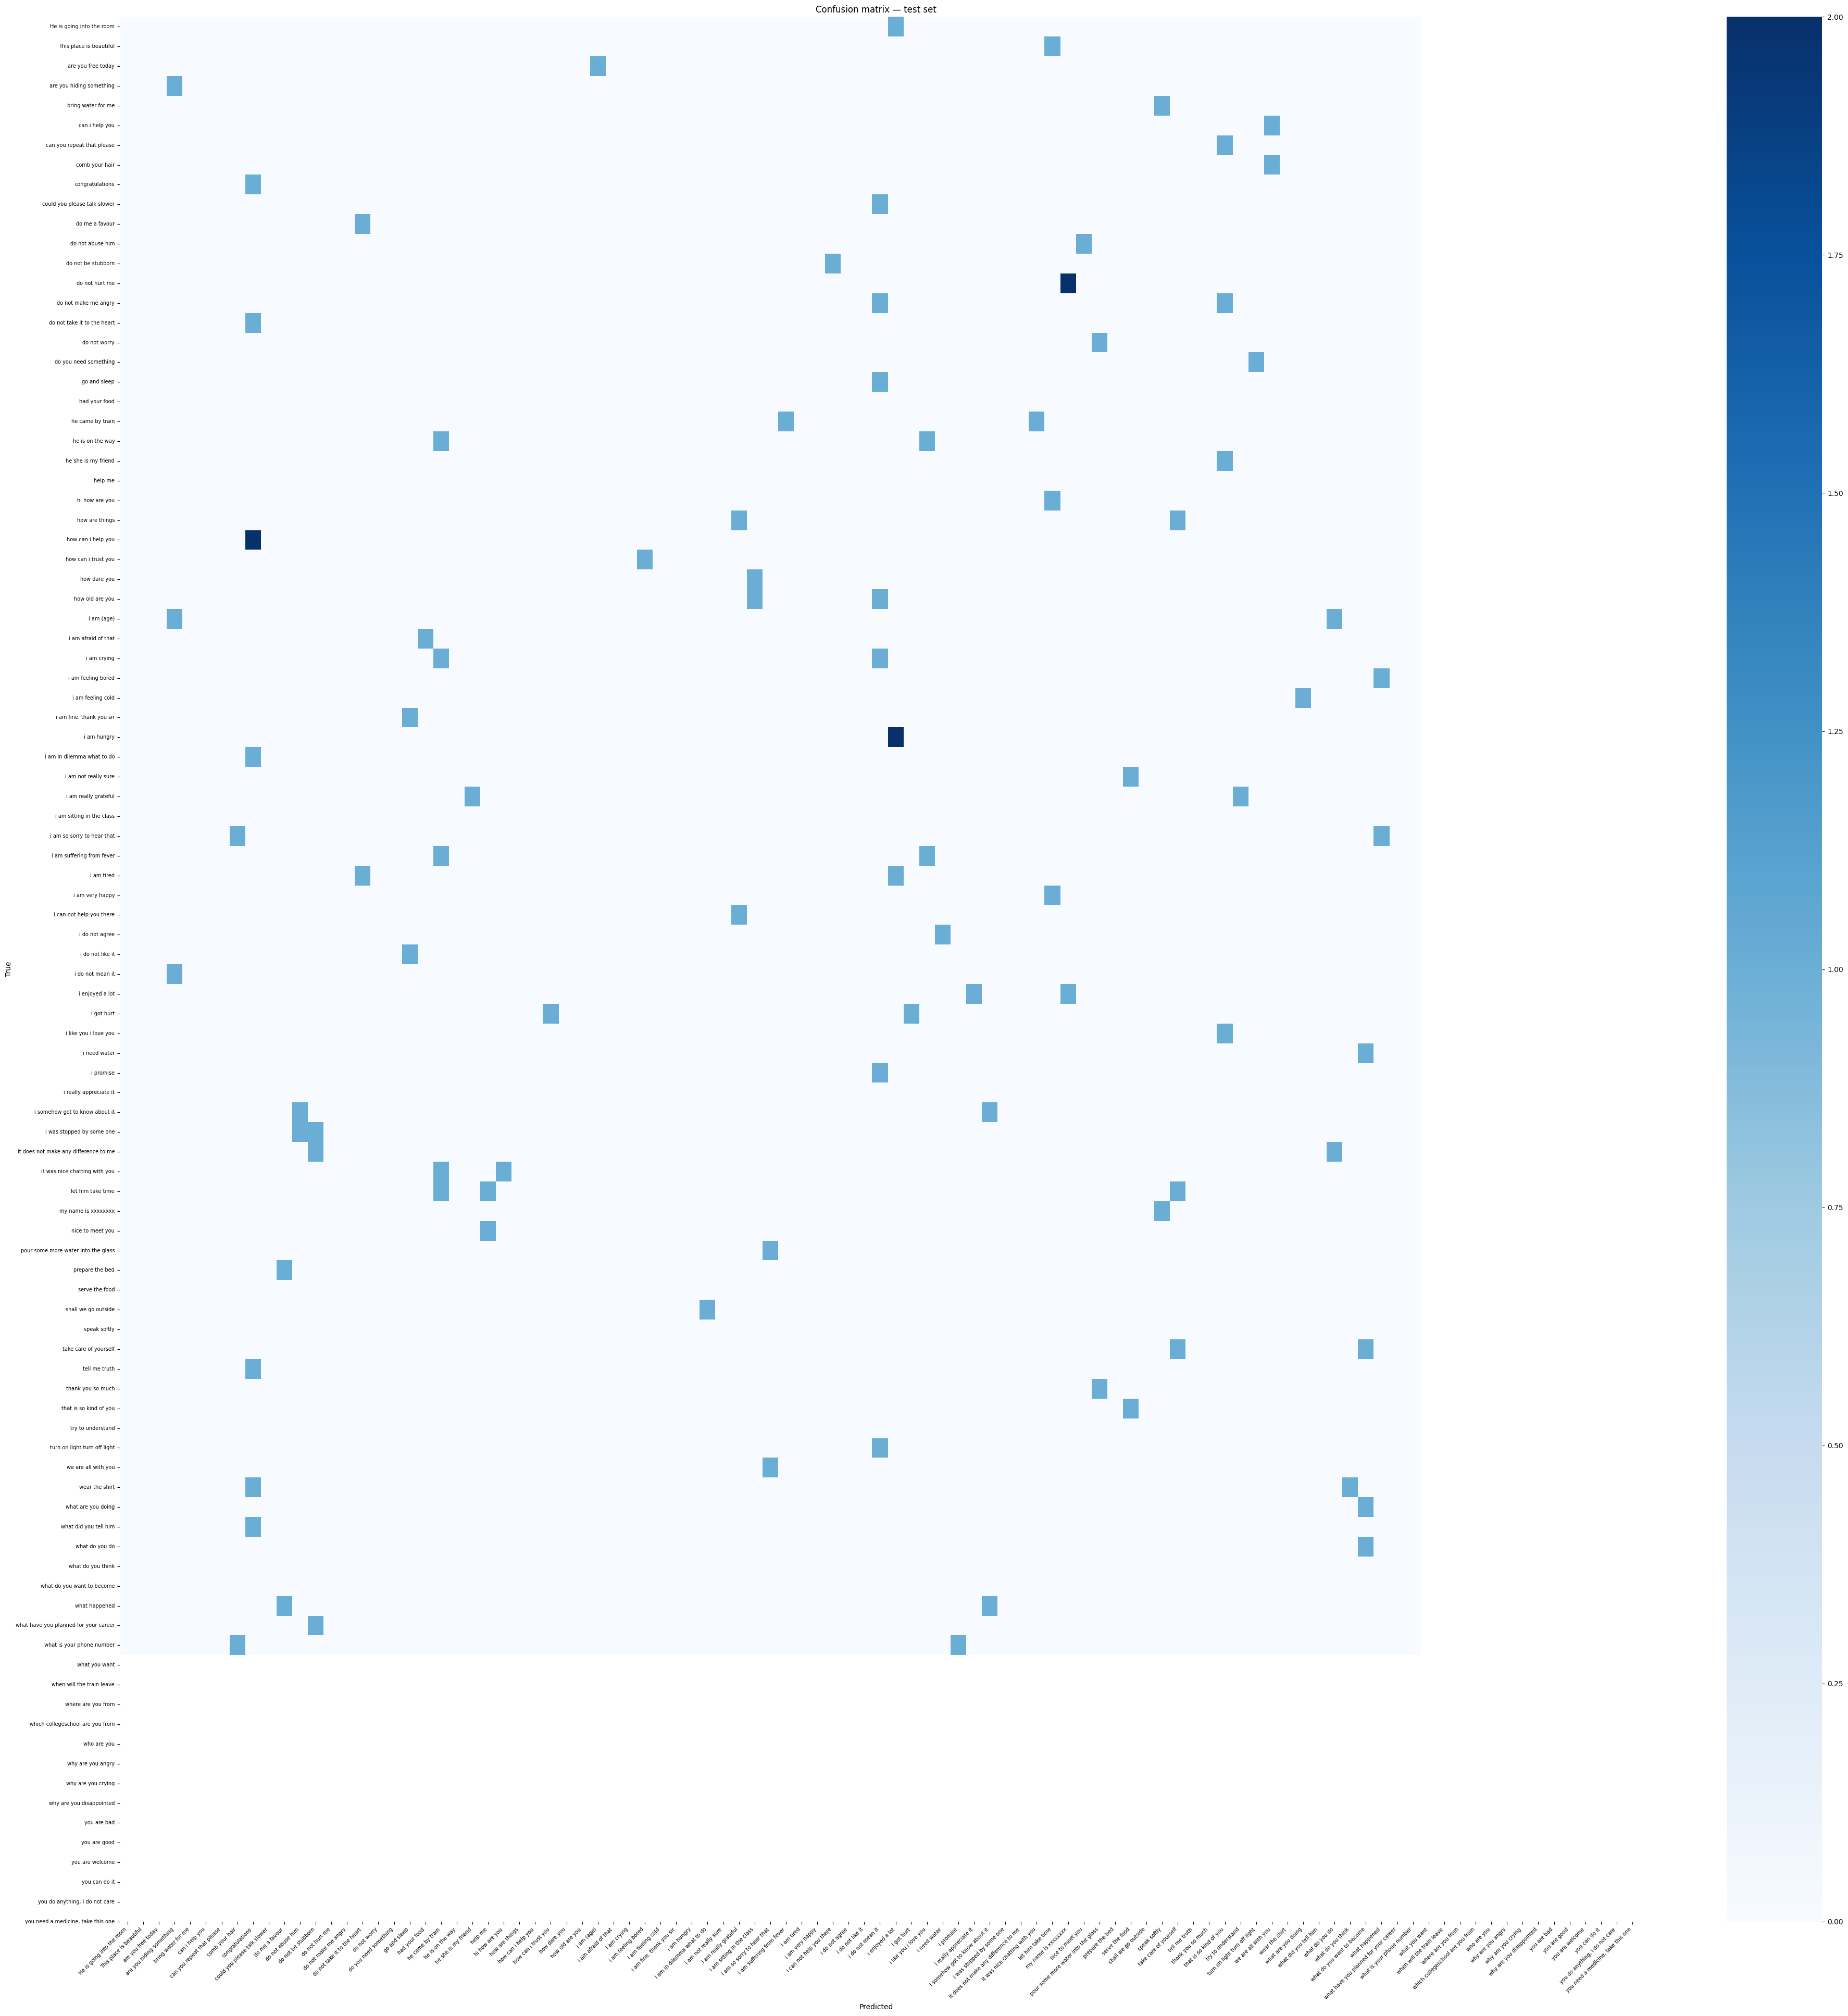

In [19]:
# Confusion matrix
cm = confusion_matrix([label_map[r] for r in refs],
                      [label_map[h] for h in hyps])
names = [id2label[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(max(8, NUM_CLASSES*0.4), max(6, NUM_CLASSES*0.4)))
sns.heatmap(cm, xticklabels=names, yticklabels=names,
            cmap="Blues", fmt="d", annot=(NUM_CLASSES<=20))
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix — test set")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()


## Section 9 — Inference
**9A** — predict from a folder of frames  
**9B** — predict from a video file  
**9C** — live webcam  
**9D** — Gradio web UI


### 9A — Predict from a frame folder

In [20]:
def predict_from_frames(folder_path):
    """Given a folder of ordered frames, return top-5 predictions."""
    kps_list = []
    with mp_holistic.Holistic(min_detection_confidence=0.5, static_image_mode=True) as h:
        for img_path in sorted(Path(folder_path).glob("*.jpg")):
            frame   = cv2.imread(str(img_path))
            if frame is None: continue
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = h.process(rgb)
            kps_list.append(extract_keypoints(results))

    if not kps_list:
        return None, "No frames found."

    seq = np.array(kps_list[:MAX_LEN], dtype=np.float32)
    T   = seq.shape[0]
    if T < MAX_LEN:
        seq = np.concatenate([seq, np.zeros((MAX_LEN-T, NUM_FEATS))], axis=0)

    model.eval()
    seq_t  = torch.tensor(seq).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out   = model(seq_t, mask_t)
        probs = out.softmax(1)[0]
        top5  = probs.topk(min(5, NUM_CLASSES))

    top_label = id2label[out.argmax(1).item()]
    ranked    = [(id2label[i.item()], f"{s.item()*100:.1f}%")
                 for s, i in zip(top5.values, top5.indices)]
    return top_label, ranked

# ── Usage ──
TEST_FOLDER = "path/to/a/frame/folder"   # ← change this to any folder from your dataset
if os.path.exists(TEST_FOLDER):
    top, ranked = predict_from_frames(TEST_FOLDER)
    print(f"🏆 Predicted: {top}")
    for lbl, conf in ranked:
        print(f"  {lbl:<35} {conf}")
else:
    print(f"Folder not found. Update TEST_FOLDER to point to any frame folder.")


Folder not found. Update TEST_FOLDER to point to any frame folder.


### 9B — Predict from a video file

In [21]:
def predict_from_video(video_path):
    kps_list = []
    cap = cv2.VideoCapture(str(video_path))
    with mp_holistic.Holistic(min_detection_confidence=0.5) as h:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = h.process(rgb)
            kps_list.append(extract_keypoints(results))
    cap.release()
    if not kps_list:
        return None, "No frames in video."
    seq = np.array(kps_list[:MAX_LEN], dtype=np.float32)
    T   = seq.shape[0]
    if T < MAX_LEN:
        seq = np.concatenate([seq, np.zeros((MAX_LEN-T, NUM_FEATS))], axis=0)
    model.eval()
    seq_t  = torch.tensor(seq).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out  = model(seq_t, mask_t)
        probs = out.softmax(1)[0]
        top5  = probs.topk(min(5, NUM_CLASSES))
    top_label = id2label[out.argmax(1).item()]
    ranked    = [(id2label[i.item()], f"{s.item()*100:.1f}%")
                 for s, i in zip(top5.values, top5.indices)]
    return top_label, ranked

VIDEO_PATH = "path/to/video.mp4"   # ← update this
if os.path.exists(VIDEO_PATH):
    top, ranked = predict_from_video(VIDEO_PATH)
    print(f"🏆 {top}")
    for l,c in ranked: print(f"  {l:<35} {c}")
else:
    print("Update VIDEO_PATH above.")


Update VIDEO_PATH above.


### 9C — Live webcam
Press **Q** to stop.

In [22]:
def run_webcam():
    model.eval()
    cap      = cv2.VideoCapture(0)
    sequence = []
    pred     = "Waiting..."
    conf     = 0.0

    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as h:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = h.process(rgb)
            sequence.append(extract_keypoints(results))

            if len(sequence) == MAX_LEN:
                seq_arr = np.array(sequence, dtype=np.float32)
                seq_t   = torch.tensor(seq_arr).unsqueeze(0).to(DEVICE)
                mask_t  = torch.ones(1, MAX_LEN).to(DEVICE)
                with torch.no_grad():
                    out   = model(seq_t, mask_t)
                    probs = out.softmax(1)[0]
                pred = id2label[out.argmax(1).item()]
                conf = probs[out.argmax(1).item()].item()
                sequence = sequence[10:]   # slide window by 10 frames

            mp_draw = mp.solutions.drawing_utils
            mp_draw.draw_landmarks(frame, results.left_hand_landmarks,
                                   mp.solutions.holistic.HAND_CONNECTIONS)
            mp_draw.draw_landmarks(frame, results.right_hand_landmarks,
                                   mp.solutions.holistic.HAND_CONNECTIONS)

            bar = int(conf * 300)
            cv2.rectangle(frame, (10,60), (10+bar,80), (0,200,100), -1)
            cv2.rectangle(frame, (10,60), (310,80), (200,200,200), 1)
            cv2.putText(frame, f"Prediction: {pred}",       (10,45),  cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,230,100), 2)
            cv2.putText(frame, f"Confidence: {conf*100:.1f}%", (10,100), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (230,230,230), 1)
            cv2.putText(frame, f"Buffer: {len(sequence)}/{MAX_LEN}", (10,120), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180,180,180), 1)
            cv2.imshow("ISL Translation  |  Q to quit", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    cap.release()
    cv2.destroyAllWindows()

run_webcam()


### 9D — Gradio web UI

In [23]:
import gradio as gr

def gradio_video(video_path):
    if not video_path: return "No video uploaded."
    top, ranked = predict_from_video(video_path)
    out  = f"### 🏆 Predicted: `{top}`\n\n**Top predictions:**\n"
    out += "\n".join(f"- `{l}` — {c}" for l,c in ranked)
    return out

def gradio_frames(frame_folder):
    if not frame_folder or not os.path.isdir(frame_folder):
        return "Enter a valid folder path containing .jpg frames."
    top, ranked = predict_from_frames(frame_folder)
    out  = f"### 🏆 Predicted: `{top}`\n\n**Top predictions:**\n"
    out += "\n".join(f"- `{l}` — {c}" for l,c in ranked)
    return out

with gr.Blocks(title="ISL Translator", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🤟 Indian Sign Language Translator\nUpload a video or enter a frames folder path.")
    with gr.Tab("Upload video"):
        vid_in  = gr.Video(label="ISL video")
        vid_out = gr.Markdown()
        gr.Button("Predict").click(gradio_video, vid_in, vid_out)
    with gr.Tab("Frame folder"):
        fold_in  = gr.Textbox(label="Path to frame folder", placeholder="C:/ISL_CSLRT_Corpus/Frames_Sentence_Level/...")
        fold_out = gr.Markdown()
        gr.Button("Predict").click(gradio_frames, fold_in, fold_out)

demo.launch(inbrowser=True, share=False)


C:\Users\harsh\AppData\Local\Temp\ipykernel_19944\1237153053.py:18: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="ISL Translator", theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Quick troubleshooting

| Problem | Fix |
|---|---|
| `utf-8 codec can't decode` | Already fixed — all CSVs now load with `encoding='latin-1'` |
| `❌ NOT FOUND` in Section 3 spot-check | `DATASET_ROOT` points to wrong folder — it must point TO `ISL_CSLRT_Corpus`, not inside it |
| `KeyError: 'Sentence'` | Run Section 3 cell 1 first and check printed column names |
| `0 sequences` after grouping | The CSV `Frames path` prefix doesn't match — print `parts` inside the loop to debug |
| CUDA out of memory | Set `"device": "cpu"` or reduce `"batch_size"` to 8 in CFG |
| `mediapipe` install error | Run `pip install mediapipe==0.10.11` in terminal |
| OpenCV window doesn't open in Jupyter | Copy `run_webcam()` to a `.py` file and run it there |
